<a href="https://colab.research.google.com/github/rpujala/machine_learning/blob/main/1.%20Introduction_to_Tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np

* Tensors are multi-dimensional arrays with a uniform type (called a dtype). You can see all supported dtypes at tf.dtypes.

* If you're familiar with NumPy, tensors are (kind of) like np.arrays.

* All tensors are immutable like Python numbers and strings: you can never update the contents of a tensor, only create a new one.

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # or any value from 0 to 3
import tensorflow as tf

#0: Shows all logs, including informational, warnings, and errors.

#1: Hides informational messages and shows warnings and errors.

#2: Hides informational and warning messages and shows only errors.

# 3: Hides all logs, including informational, warnings, and errors.

## Basics

In [ ]:
tensor = tf.constant(4)
print(tensor)

tf.Tensor(4, shape=(), dtype=int32)


In [ ]:
rank_0_tensor = tf.constant(4)
print(rank_0_tensor)

tf.Tensor(4, shape=(), dtype=int32)


In [ ]:
rank_0_tensor.shape, rank_0_tensor.dtype

(TensorShape([]), tf.int32)

A "vector" or "rank-1" tensor is like a list of values. A vector has one axis:


In [ ]:
rank_1_tensor = tf.constant([2.0, 3.1, 4.2])
print(rank_1_tensor)

tf.Tensor([2.  3.1 4.2], shape=(3,), dtype=float32)


In [ ]:
rank_1_tensor.shape

TensorShape([3])

In [ ]:
rank_1_tensor.dtype

tf.float32

A "matrix" or "rank-2" tensor has two axes:

In [ ]:
rank_2_tensor = tf.constant([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(rank_2_tensor)

tf.Tensor(
[[1 2 3]
 [4 5 6]
 [7 8 9]], shape=(3, 3), dtype=int32)


In [ ]:
rank_2_tensor.shape

TensorShape([3, 3])

In [ ]:
rank_2_tensor.dtype

tf.int32

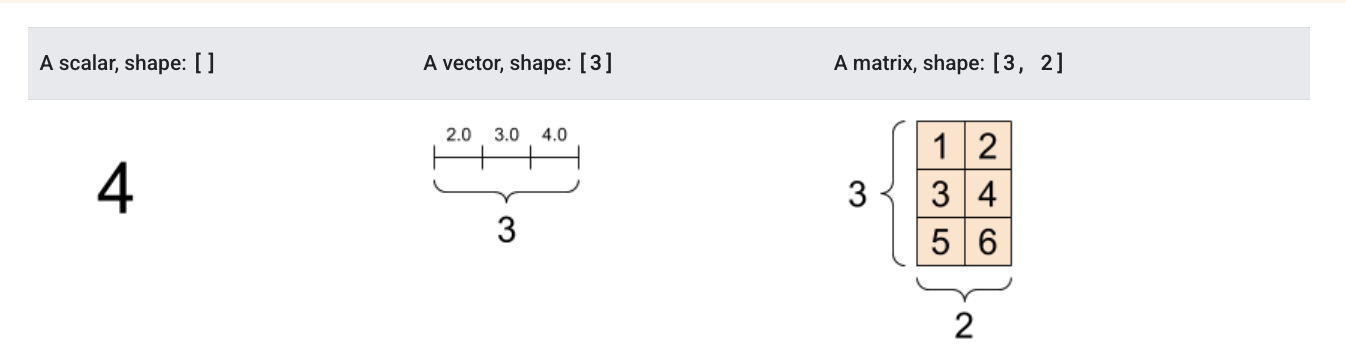

Tensors may have more axes; here is a tensor with three axes:

In [ ]:
# There can be an arbitrary number of
# axes (sometimes called "dimensions")

rank_3_tensor = tf.constant([
    [
        [0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]
    ],
    [
        [10, 11, 12, 13, 13.5],
        [14, 15, 16, 17, 17.1]
    ]
])

print(rank_3_tensor)

tf.Tensor(
[[[ 0.   1.   2.   3.   4. ]
  [ 5.   6.   7.   8.   9. ]]

 [[10.  11.  12.  13.  13.5]
  [14.  15.  16.  17.  17.1]]], shape=(2, 2, 5), dtype=float32)


In [ ]:
rank_3_tensor.shape

TensorShape([2, 2, 5])

In [ ]:
rank_3_tensor.dtype

tf.float32

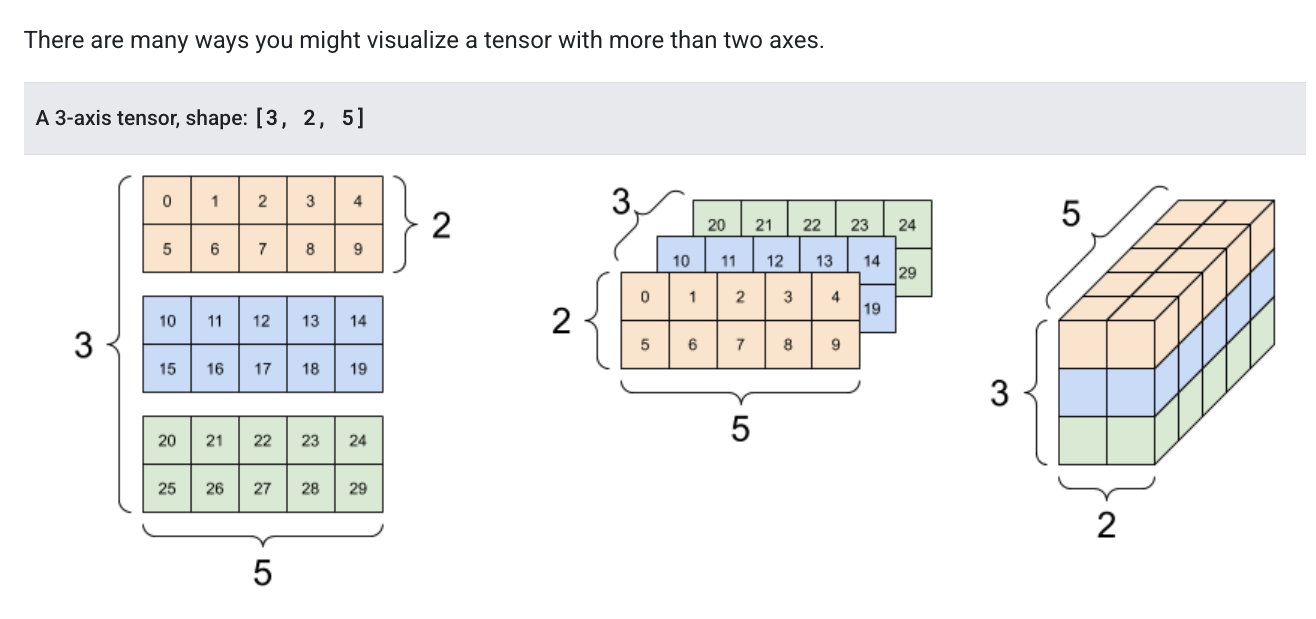

You can convert a tensor to a NumPy array either using np.array or the tensor.numpy method:


In [ ]:
rank_2_tensor

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]], dtype=int32)>

In [ ]:
np.array(rank_2_tensor)

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]], dtype=int32)

In [ ]:
rank_2_tensor.numpy()

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]], dtype=int32)

Tensors often contains floats and ints, but have many other types, including:

* Complex numbers
* Strings

The base **tf.Tensor** class requires tensors to be "rectangular" - that is along each axis, every element is the same size.

Howeever, there are specialized types of tensors that can handle different shapes:

* Ragged tensors
* Sparse tensors

In [ ]:
tf.ones([2, 2]).numpy()

array([[1., 1.],
       [1., 1.]], dtype=float32)

In [ ]:
tf.zeros([2, 2]).numpy()

array([[0., 0.],
       [0., 0.]], dtype=float32)

In [ ]:
a = tf.constant([
    [1, 2],
    [3, 4]
])

b = tf.constant([
    [1, 1],
    [1, 2]
])

print(tf.add(a, b))

tf.Tensor(
[[2 3]
 [4 6]], shape=(2, 2), dtype=int32)


In [ ]:
print(tf.multiply(a, b))

tf.Tensor(
[[1 2]
 [3 8]], shape=(2, 2), dtype=int32)


In [ ]:
print(tf.matmul(a, b))

tf.Tensor(
[[ 3  5]
 [ 7 11]], shape=(2, 2), dtype=int32)


In [ ]:
print(a + b)

tf.Tensor(
[[2 3]
 [4 6]], shape=(2, 2), dtype=int32)


In [ ]:
print(a * b)

tf.Tensor(
[[1 2]
 [3 8]], shape=(2, 2), dtype=int32)


In [ ]:
print(a @ b)

tf.Tensor(
[[ 3  5]
 [ 7 11]], shape=(2, 2), dtype=int32)


Typically, anywhere a TensorFlow function expects a **Tensor** as input, the function will also accept anything that can be converted as a **Tensor** using **tf.convert_to_tensor**

In [ ]:
tf.convert_to_tensor([1, 2, 3])

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [ ]:
tf.reduce_max([1, 2, 3])

<tf.Tensor: shape=(), dtype=int32, numpy=3>

In [ ]:
tf.reduce_max(np.array([1, 2, 3]))

<tf.Tensor: shape=(), dtype=int64, numpy=3>

## Shapes

* Tensors have shapes. Some vocabulary:
  * **Shape:** The length (number of elements) of each of the axes of a tensor
  * **Rank:** Number of tensor axes. A scalar has rank 0, a vector has rank 1, a matrix is rank 2
  * **Axis or Dimension:** A particular dimension of a tensor
  * **Size:** The total number of items in the tensor, the product of the shape vector's elements

Note: Although you may see reference to a "tensor of two dimensions", a rank-2 tensor does not usually describe a 2D space.


In [ ]:
rank_4_tensor = tf.zeros([3, 2, 4, 5])
rank_4_tensor

<tf.Tensor: shape=(3, 2, 4, 5), dtype=float32, numpy=
array([[[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

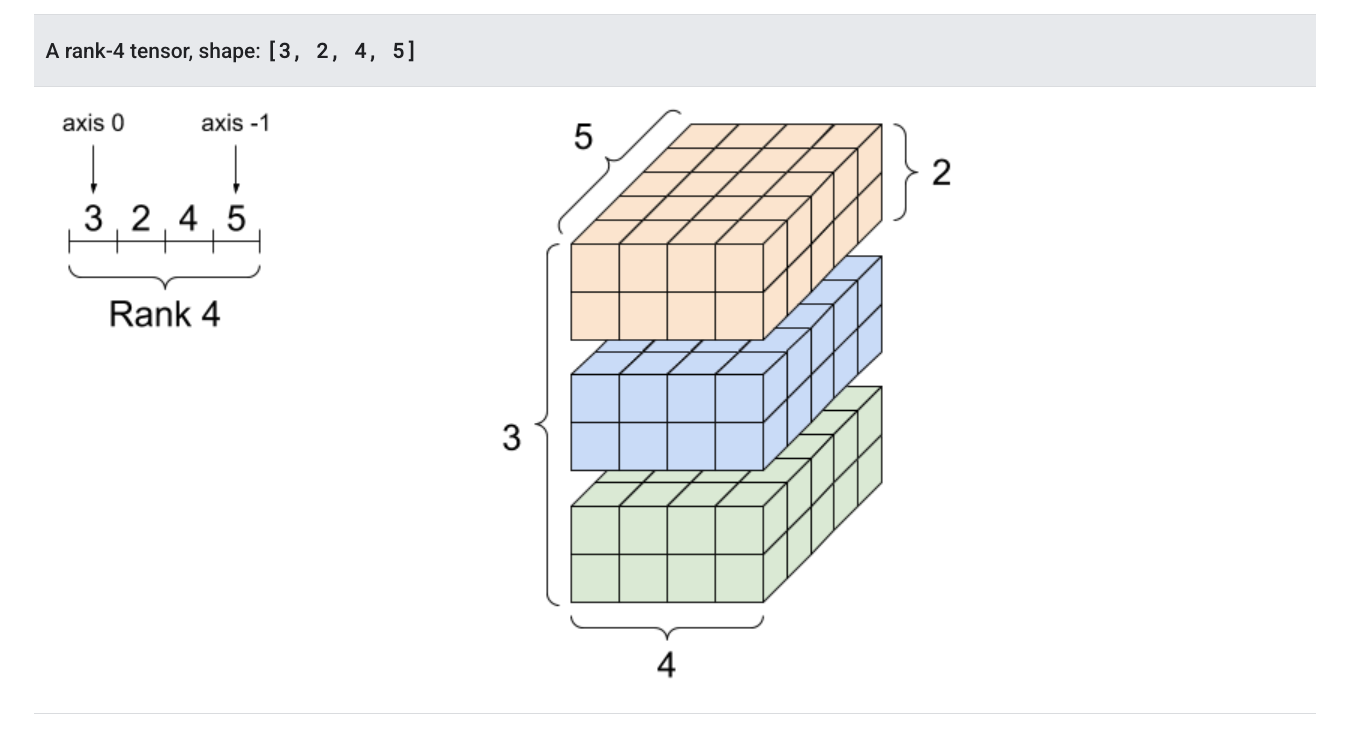

In [ ]:
print("Type of every element: ", rank_4_tensor.dtype)
print("Number of axes: ", rank_4_tensor.ndim)
print("Shape of tensor: ", rank_4_tensor.shape)
print("Elements along axis 0 of a tensor: ", rank_4_tensor.shape[0])
print("Elements alonf the last axis of a tensor: " ,rank_4_tensor.shape[-1])
print("Total number of elements (3 * 2 * 4 * 5): ", tf.size(rank_4_tensor).numpy())

Type of every element:  <dtype: 'float32'>
Number of axes:  4
Shape of tensor:  (3, 2, 4, 5)
Elements along axis 0 of a tensor:  3
Elements alonf the last axis of a tensor:  5
Total number of elements (3 * 2 * 4 * 5):  120


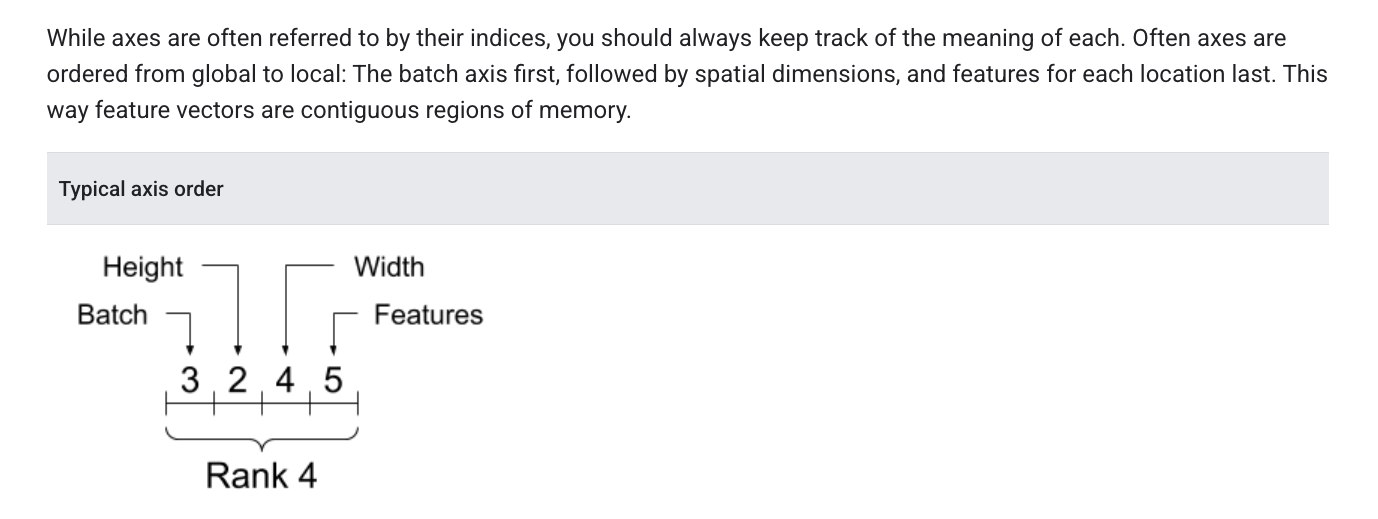

## Indexing

### Single - axis Indexing

* Tensorflow follows standard Python Indexing rules, similar to Indexing a list or a string in Python, and the basic rules for NumPy Indexing:
  * indexes start at 0
  * negative indices count backwards from the end
  * colons, :, are used for slices: **start:stop:step**

In [ ]:
rank_1_tensor = tf.constant([0, 1, 1, 2, 3, 4, 5, 8, 13, 21])
print(rank_1_tensor)

tf.Tensor([ 0  1  1  2  3  4  5  8 13 21], shape=(10,), dtype=int32)


In [ ]:
print(f"First: {rank_1_tensor[0].numpy()}")

First: 0


In [ ]:
print(f"Second: {rank_1_tensor[1].numpy()}")

Second: 1


In [ ]:
print(f"Last: {rank_1_tensor[-1].numpy()}")

Last: 21


In [ ]:
print(f"Everything: {rank_1_tensor[:].numpy()}")

Everything: [ 0  1  1  2  3  4  5  8 13 21]


In [ ]:
print("Before 4:", rank_1_tensor[:4].numpy())
print("From 4 to the end:", rank_1_tensor[4:].numpy())
print("From 2, before 7:", rank_1_tensor[2:7].numpy())
print("Every other item:", rank_1_tensor[::2].numpy())
print("Reversed:", rank_1_tensor[::-1].numpy())

Before 4: [0 1 1 2]
From 4 to the end: [ 3  4  5  8 13 21]
From 2, before 7: [1 2 3 4 5]
Every other item: [ 0  1  3  5 13]
Reversed: [21 13  8  5  4  3  2  1  1  0]


## Multi-axis indexing

* Higher rank tensors are indexed by passing multiple indices
* The exact same rules as in the single axis case apply to each axis independently

In [ ]:
print(rank_2_tensor.numpy())

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [ ]:
# Passing an integer for each index, the result is a scalar.

# Pull out a single value from a 2-rank tensor
print(rank_2_tensor[1, 1].numpy())

5


In [ ]:
# Get row and column tensors
print("Second row:", rank_2_tensor[1, :].numpy())
print("Second column:", rank_2_tensor[:, 1].numpy())
print("Last row:", rank_2_tensor[-1, :].numpy())
print("First item in last column:", rank_2_tensor[0, -1].numpy())
print("Skip the first row:")
print(rank_2_tensor[1:, :].numpy(), "\n")

Second row: [4 5 6]
Second column: [2 5 8]
Last row: [7 8 9]
First item in last column: 3
Skip the first row:
[[4 5 6]
 [7 8 9]] 



In [ ]:
print(rank_3_tensor[:, :, 4])

tf.Tensor(
[[ 4.   9. ]
 [13.5 17.1]], shape=(2, 2), dtype=float32)


Selecting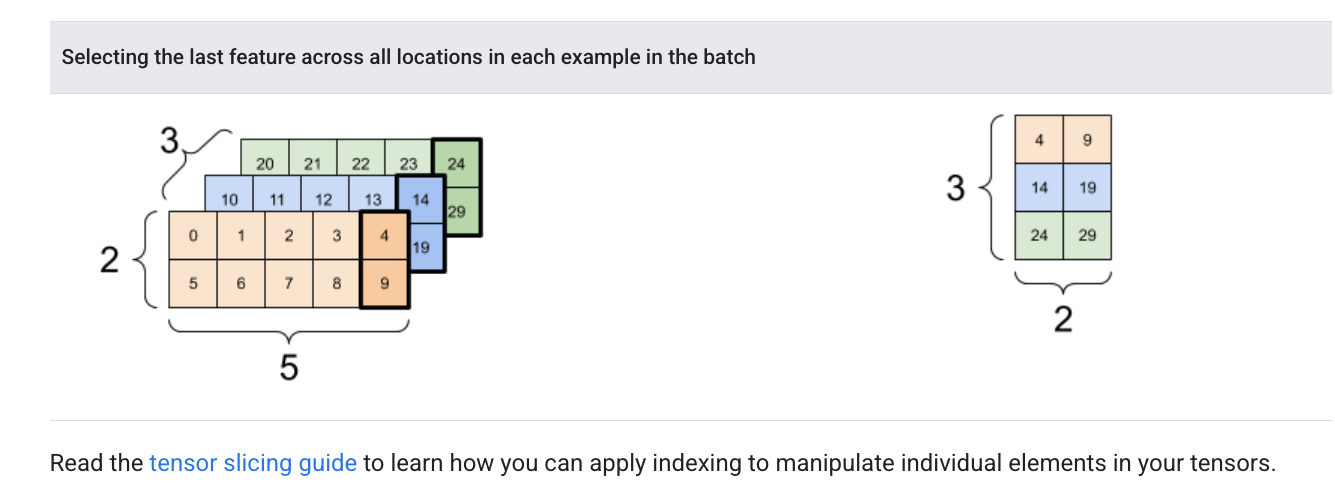

## Manipulating Shapes

* Reshaping a tensor is of great utility


In [ ]:
x = tf.constant([
    [1], [2], [3]
])
print(x.shape)

(3, 1)


In [ ]:
# You can convert this object into a Python list, too

print(x.shape.as_list())

[3, 1]


You can reshape a tensor into a new shape. The **tf.reshape** operation is fast and cheap as the underlying data does not need to be duplicated

In [ ]:
reshaped = tf.reshape(x, [1, 3])
reshaped

<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[1, 2, 3]], dtype=int32)>

In [ ]:
print(reshaped.shape)
print(x.shape)

(1, 3)
(3, 1)


The data maintains its layout in memory and a new tensor is created, with the requested shape, pointing to the same data. TensorFlow uses C-style "row-major" memory ordering, where incrementing the rightmost index corresponds to a single step in memory.



If you flatten a tensor you can see what order it is laid out in memory.



In [ ]:
# A `-1` passed in the `shape` argument says "Whatever fits".
print(tf.reshape(rank_3_tensor, [-1]))

tf.Tensor(
[ 0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
 13.5 14.  15.  16.  17.  17.1], shape=(20,), dtype=float32)


Typically the only reasonable use of tf.reshape is to combine or split adjacent axes (or add/remove 1s).

For this 3x2x5 tensor, reshaping to (3x2)x5 or 3x(2x5) are both reasonable things to do, as the slices do not mix:

## More on DTypes

In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
f64_tensor = tf.constant([2.2, 3.4, 4.2], dtype=tf.float64)
f32_tensor = tf.cast(f64_tensor, dtype=tf.float32)
f16_tensor = tf.cast(f32_tensor, dtype=tf.float32)
f8_tensor = tf.cast(f16_tensor, dtype=tf.uint8)
print(f8_tensor)

tf.Tensor([2 3 4], shape=(3,), dtype=uint8)


## Broadcasting

* Broadcating is a concept borrowed from the **equivalent features in NumPy**. In short, under certain conditions, small tensors are "stretched" automatically to fit larger tensors when running combined operations on them.

* The simplest and most common case is when you attempt to multiply or add a tensor to a scalar.

* In that case, the scalar is broadcast to be the same shape as the other argument

In [ ]:
x = tf.constant([1, 2, 3])

y = tf.constant(2)

z = tf.constant([2, 2, 2])

# All of these are the same computation
print(tf.multiply(x, 2))
print(x * y)
print(x * z)

tf.Tensor([2 4 6], shape=(3,), dtype=int32)
tf.Tensor([2 4 6], shape=(3,), dtype=int32)
tf.Tensor([2 4 6], shape=(3,), dtype=int32)


Likewise, axes with length 1 can be stretched out to match the other arguments. Both arguments can be stretched in the same computation.

In this case a 3x1 matrix is element-wise multiplied by a 1x4 matrix to produce a 3x4 matrix. Note how the leading 1 is optional: The shape of y is [4].

In [ ]:
# These are the same computations
x = tf.reshape(x,[3,1])
y = tf.range(1, 5)
print(x, "\n")
print(y, "\n")
print(tf.multiply(x, y))

tf.Tensor(
[[1]
 [2]
 [3]], shape=(3, 1), dtype=int32) 

tf.Tensor([1 2 3 4], shape=(4,), dtype=int32) 

tf.Tensor(
[[ 1  2  3  4]
 [ 2  4  6  8]
 [ 3  6  9 12]], shape=(3, 4), dtype=int32)


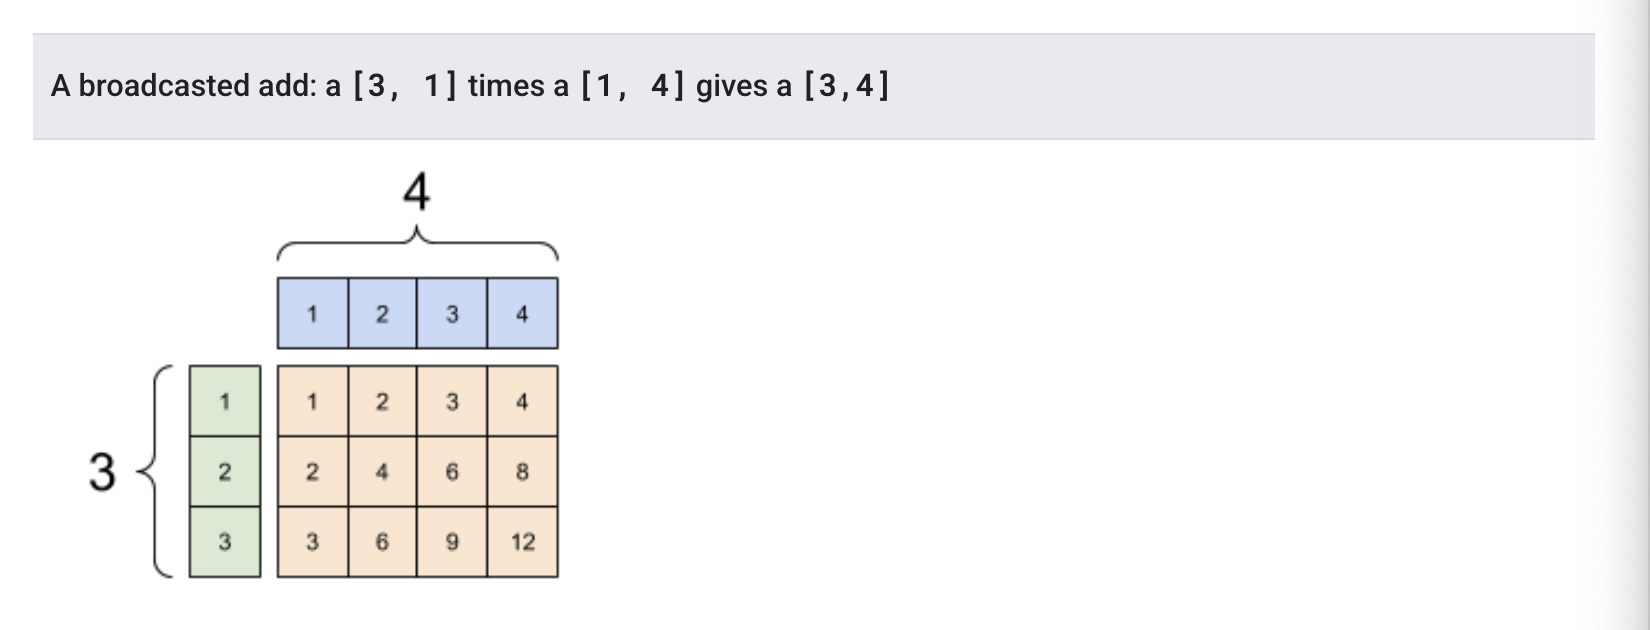

**Here is the same operation without broadcasting:**

In [ ]:
x_stretch = tf.constant([
    [1, 1, 1, 1],
    [2, 2, 2, 2],
    [3, 3, 3, 3]
])

y_stretch = tf.constant([
    [1, 2, 3, 4],
    [1, 2, 3, 4],
    [1, 2, 3, 4]
])

print(x_stretch * y_stretch)

tf.Tensor(
[[ 1  2  3  4]
 [ 2  4  6  8]
 [ 3  6  9 12]], shape=(3, 4), dtype=int32)


* Most of the time, broadcasting is both time and space efficient, as the broadcast operation never materializes the expanded tensors in memory.

* You see what broadcasting looks like **tf.broadcast_to**

In [ ]:
tf.broadcast_to(tf.constant([1, 2, 3]), [3, 3])

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [1, 2, 3],
       [1, 2, 3]], dtype=int32)>

Unlike a mathematical op, for example, broadcast_to does nothing special to save memory. Here, you are materializing the tensor.

## tf.convert_to_tensor

* Most ops, like **tf.matmul** and **tf.reshape** take arguments of class **tf.Tensor**. However, you'll notice in the above case, Python objects shaped like tensors are accepted.

* Most, but not all, ops call convert_to_tensor on non-tensor arguments. There is a registry of conversions, and most object classes like NumPy's ndarray, TensorShape, Python lists, and **tf.Variable** will all convert automatically.

* See **tf.register_tensor_conversion_function** for more details, and if you have your own type you'd like to automatically convert to a tensor.

## Ragged Tensors

A tensor with variable numbers of elements along some axis is called "ragged". Use **tf.ragged.RaggedTensor** for ragged data.

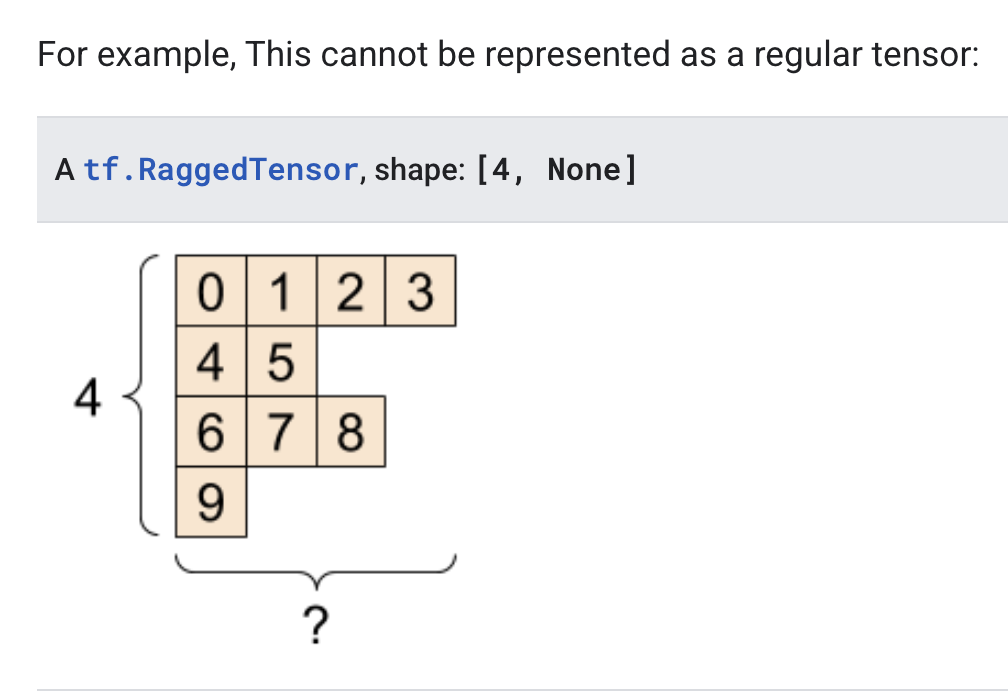

In [ ]:
ragged_list = [
    [0, 1, 2, 3],
    [4, 5],
    [6, 7, 8],
    [9]
]

ragged_list

[[0, 1, 2, 3], [4, 5], [6, 7, 8], [9]]

In [ ]:
try:
  tensor = tf.constant(ragged_list)
except Exception as e:
  print(f"{type(e).__name__}: {e}")

ValueError: Can't convert non-rectangular Python sequence to Tensor.


Instead create a **tf.RaggedTensor**using **tf.ragged.constant**:



In [ ]:
ragged_tensor = tf.ragged.constant(ragged_list)
print(ragged_tensor)

<tf.RaggedTensor [[0, 1, 2, 3], [4, 5], [6, 7, 8], [9]]>


The shape of a tf.RaggedTensor will contain some axes with unknown lengths:



In [ ]:
print(ragged_tensor.shape)

(4, None)


## String Tensors

* **tf.string** is a dtype, which is to say you can represent data as strings (variable-length byte arrays) in tensors.

* The strings are atomic and cannot be indexed the way Python strings are. The length of the string is not one of the axes of the tensor. See **tf.strings** for functions to manipulate them.

* Here is a scalar string tensor:




In [ ]:
# Tensors can be strings, too here is a scalar string.

scalar_string_tensor = tf.constant("Gray wolf")
print(scalar_string_tensor)

tf.Tensor(b'Gray wolf', shape=(), dtype=string)


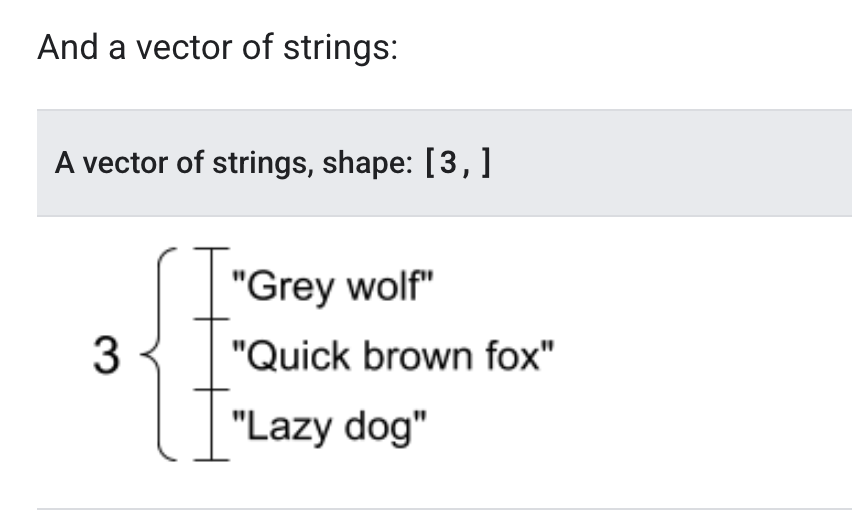

In [ ]:
# If you have three string tensors of different lengths, this is OK.

tensor_of_strings = tf.constant([
    "Gray wolf",
    "Quick brown fox",
    "Lazy dog"
])

print(tensor_of_strings)

tf.Tensor([b'Gray wolf' b'Quick brown fox' b'Lazy dog'], shape=(3,), dtype=string)


In the above printout the b prefix indicates that tf.string dtype is not a unicode string, but a byte-string. See the Unicode Tutorial for more about working with unicode text in TensorFlow.

If you pass unicode characters they are utf-8 encoded.

In [ ]:
tf.constant("🥳👍")

<tf.Tensor: shape=(), dtype=string, numpy=b'\xf0\x9f\xa5\xb3\xf0\x9f\x91\x8d'>

Some basic functions with strings can be found in tf.strings, including tf.strings.split.



In [ ]:
# You can use split to split a string into a set of tensors
print(tf.strings.split(scalar_string_tensor, sep=" "))

tf.Tensor([b'Gray' b'wolf'], shape=(2,), dtype=string)


In [ ]:
# ...but it turns into a `RaggedTensor` if you split up a tensor of strings,
# as each string might be split into a different number of parts.
print(tf.strings.split(tensor_of_strings))

<tf.RaggedTensor [[b'Gray', b'wolf'], [b'Quick', b'brown', b'fox'], [b'Lazy', b'dog']]>


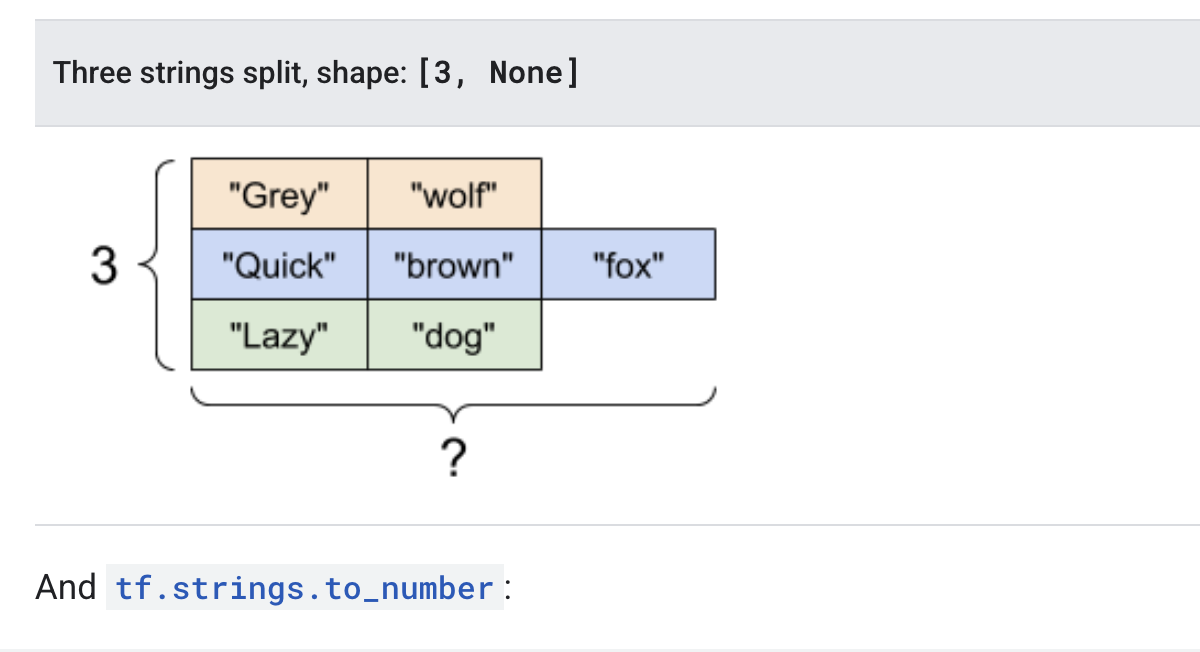

In [ ]:
text = tf.constant("1 10 100")
print(tf.strings.to_number(tf.strings.split(text, " ")))

tf.Tensor([  1.  10. 100.], shape=(3,), dtype=float32)


Although you can't use tf.cast to turn a string tensor into numbers, you can convert it into bytes, and then into numbers.



In [ ]:
byte_strings = tf.strings.bytes_split(tf.constant("Duck"))
byte_ints = tf.io.decode_raw(tf.constant("Duck"), tf.uint8)
print("Byte strings:", byte_strings)
print("Bytes:", byte_ints)

Byte strings: tf.Tensor([b'D' b'u' b'c' b'k'], shape=(4,), dtype=string)
Bytes: tf.Tensor([ 68 117  99 107], shape=(4,), dtype=uint8)


In [ ]:
# Or split it up as unicode and then decode it
unicode_bytes = tf.constant("アヒル 🦆")
unicode_char_bytes = tf.strings.unicode_split(unicode_bytes, "UTF-8")
unicode_values = tf.strings.unicode_decode(unicode_bytes, "UTF-8")

print("\nUnicode bytes:", unicode_bytes)
print("\nUnicode chars:", unicode_char_bytes)
print("\nUnicode values:", unicode_values)


Unicode bytes: tf.Tensor(b'\xe3\x82\xa2\xe3\x83\x92\xe3\x83\xab \xf0\x9f\xa6\x86', shape=(), dtype=string)

Unicode chars: tf.Tensor([b'\xe3\x82\xa2' b'\xe3\x83\x92' b'\xe3\x83\xab' b' ' b'\xf0\x9f\xa6\x86'], shape=(5,), dtype=string)

Unicode values: tf.Tensor([ 12450  12498  12523     32 129414], shape=(5,), dtype=int32)


The tf.string dtype is used for all raw bytes data in TensorFlow. The tf.io module contains functions for converting data to and from bytes, including decoding images and parsing csv.



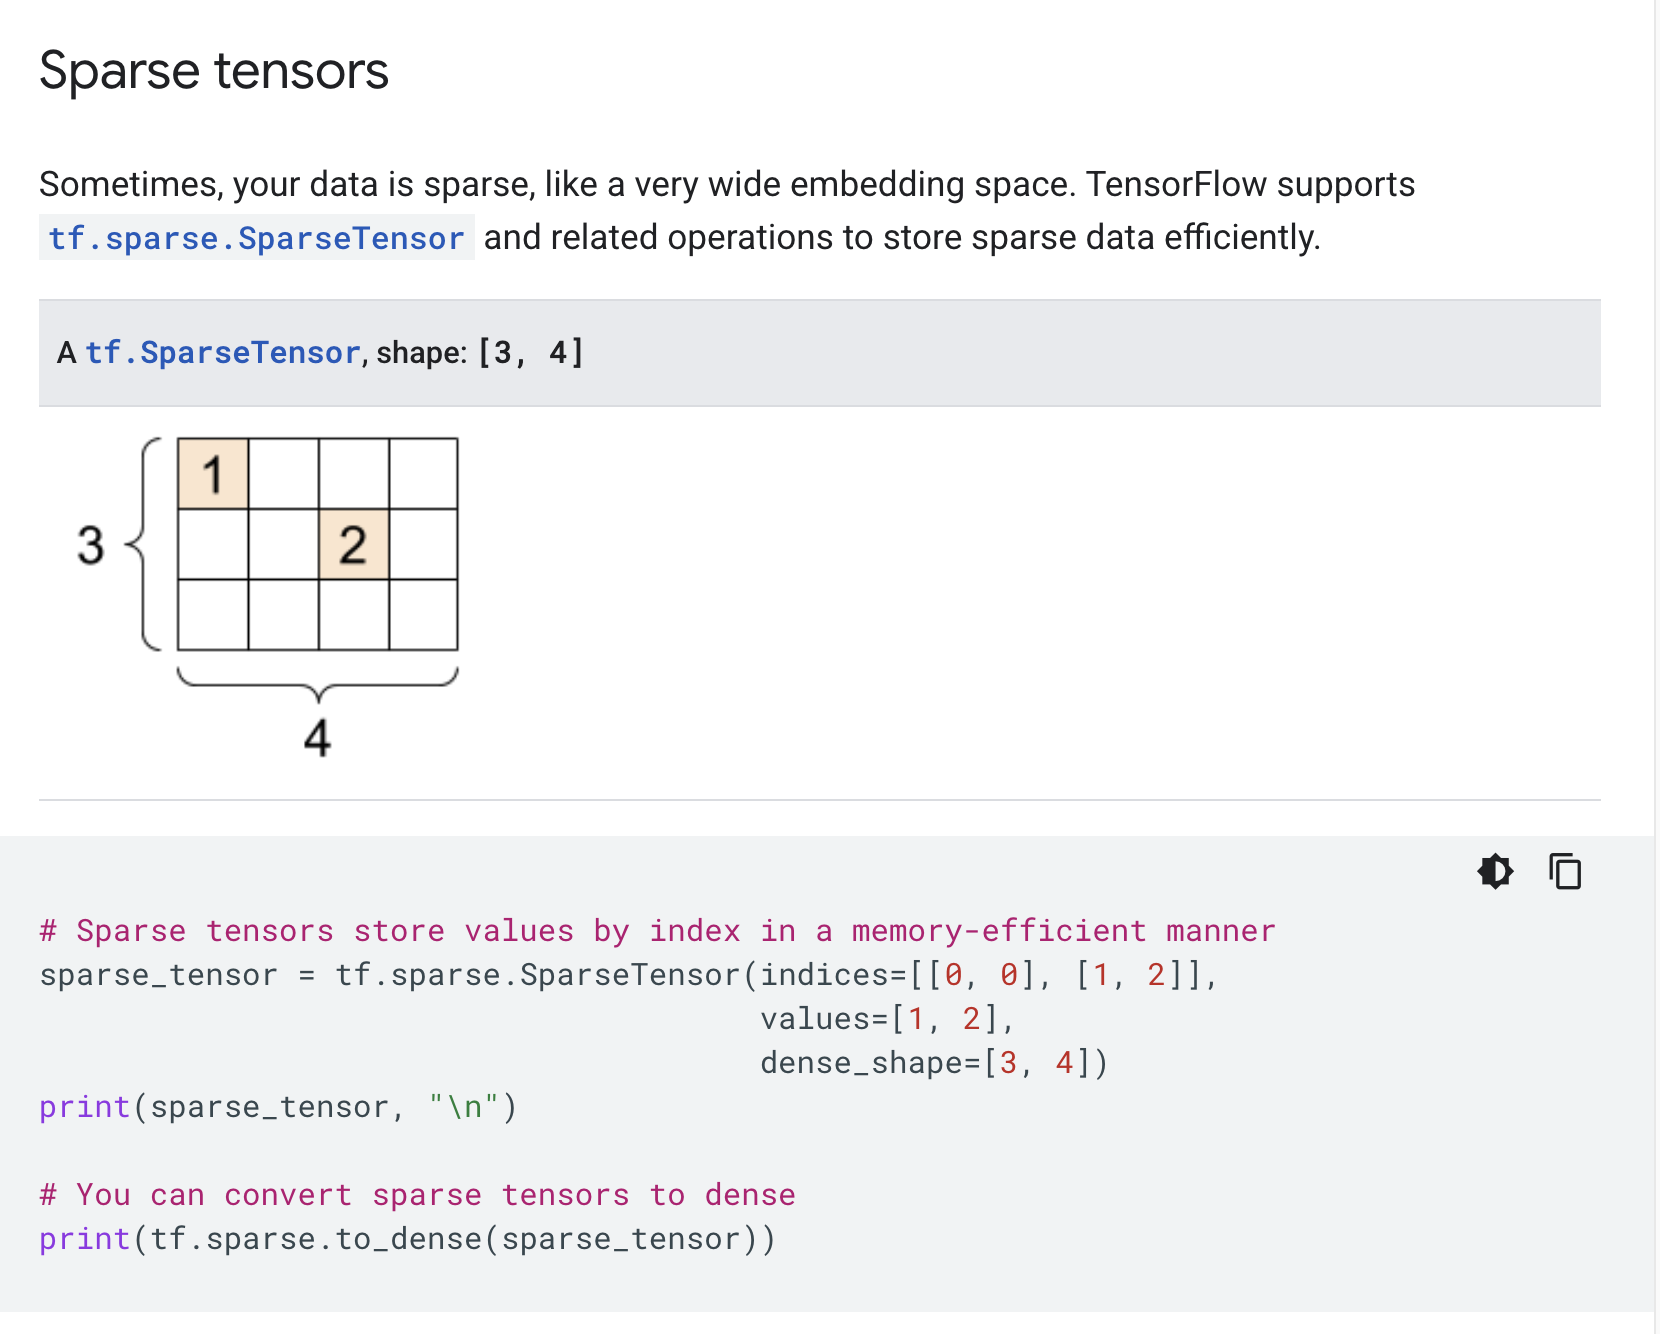